## Exploratory Data Analysis

In [145]:
pip install hdbscan

   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   -------------------------- ------------- 1.3/1.9 MB 7.6 MB/s eta 0:00:01
   ---------------------------------------- 1.9/1.9 MB 5.6 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [146]:
#Libraries needed: 

# Python libraries:
import random as rd
import math
from collections import Counter

#Data Manipulation:
import pandas as pd
import numpy as np

#Visualization: 
import seaborn as sns
import matplotlib.pyplot as plt
import hdbscan
from matplotlib.patches import Patch

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Unsupervised Models
from sklearn.decomposition import PCA
import umap.umap_ as umap

In [77]:
# read in csv file
finalseq_df = pd.read_csv('finalseq_df.csv')

finalseq_df.head(5)

,hotspot,mutation_rate,wuhan_resnum,rsa,asa,q8,p[q8_G],p[q8_H],p[q8_I],p[q8_B],...,positive,special,charge_ref,charge_win9,charge_win15,charge_win21,gp_ref,gp_win9,gp_win15,gp_win21
0,1,0.04,1.0,0.660813,148.022039,C,0.000175,0.000576,0.000018,0.000184,...,0,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.090909
1,1,0.04,2.0,0.682652,163.836508,C,0.000101,0.000402,0.000006,0.000074,...,0,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.111111,0.083333
2,1,0.06,3.0,0.672084,116.942663,C,0.000074,0.000361,0.000003,0.000033,...,0,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.100000,0.076923
3,1,0.04,4.0,0.665079,159.619060,C,0.000071,0.000366,0.000002,0.000030,...,0,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.090909,0.071429
4,1,0.04,5.0,0.662311,133.124503,C,0.000074,0.000376,0.000003,0.000034,...,0,0,0.0,0.0,0.0,0.0,0.0,0.111111,0.083333,0.066667


In [159]:
finalseq_df["hotspot"].value_counts()

hotspot
0    1144
1     129
Name: count, dtype: int64

###  Plots 

  q8  Non-hotspot  Hotspot  Total  Hotspot_Rate
0  C          427       70    497     14.084507
4  T           85       10     95     10.526316
1  E          366       35    401      8.728180
2  H          249       14    263      5.323194
3  S           17        0     17      0.000000


<function matplotlib.pyplot.show(close=None, block=None)>

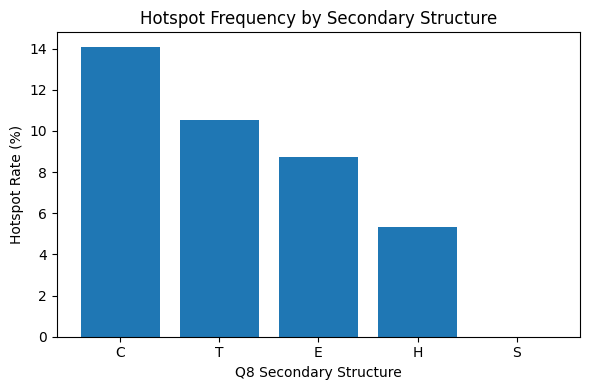

In [55]:
#frequency table for secondary structures

summary_ss = (
    pd.crosstab(finalseq_df["q8"],finalseq_df["hotspot"])
    .rename(columns = {0: "Non-hotspot", 1: "Hotspot"})
    )
    
summary_ss["Total"] = (
    summary_ss["Non-hotspot"] + summary_ss["Hotspot"]
)

summary_ss["Hotspot_Rate"] = (
    summary_ss["Hotspot"]/summary_ss["Total"] * 100
)
summary_ss.columns.name = None
summary_ss = summary_ss.reset_index().sort_values(by = "Hotspot_Rate",ascending = False)

print(summary_ss)

#bar chart
plt.figure(figsize = (6,4))

plt.bar(summary_ss["q8"],summary_ss["Hotspot_Rate"])
plt.xlabel("Q8 Secondary Structure")
plt.ylabel("Hotspot Rate (%)")
plt.title("Hotspot Frequency by Secondary Structure")

plt.tight_layout()
plt.show

     chem_prop  Non-hotspot  Hotspot  Total  Hotspot_Rate
3     positive          105       15    120     12.500000
2        polar          308       38    346     10.982659
1     negative           98       12    110     10.909091
0  hydrophobic          467       50    517      9.671180
4      special          166       14    180      7.777778


<function matplotlib.pyplot.show(close=None, block=None)>

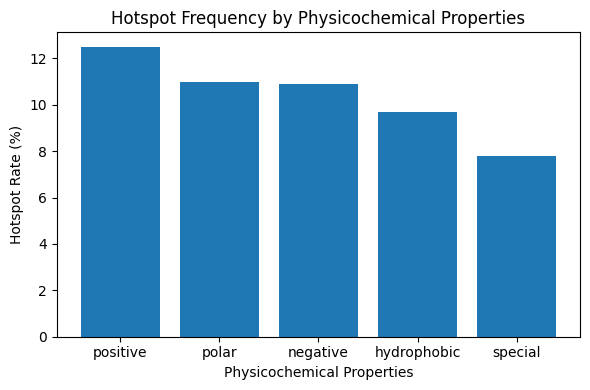

In [56]:
#frequency table for chemical properties

summary_chem = (
    pd.crosstab(finalseq_df["chem_prop"],finalseq_df["hotspot"])
    .rename(columns = {0: "Non-hotspot", 1: "Hotspot"})
    )
    
summary_chem["Total"] = (
    summary_chem["Non-hotspot"] + summary_chem["Hotspot"]
)

summary_chem["Hotspot_Rate"] = (
    summary_chem["Hotspot"]/summary_chem["Total"] * 100
)
summary_chem.columns.name = None
summary_chem = summary_chem.reset_index().sort_values(by = "Hotspot_Rate",ascending = False)

print(summary_chem)

#bar chart
plt.figure(figsize = (6,4))

plt.bar(summary_chem["chem_prop"],summary_chem["Hotspot_Rate"])
plt.xlabel("Physicochemical Properties")
plt.ylabel("Hotspot Rate (%)")
plt.title("Hotspot Frequency by Physicochemical Properties")

plt.tight_layout()
plt.show

In [161]:
#summary of physicochemical properties

summary_rsa = finalseq_df.groupby("hotspot")["rsa"].describe()
summary_rsa

,count,mean,std,min,25%,50%,75%,max
hotspot,,,,,,,,
0,1144.0,0.340139,0.173655,0.020385,0.192989,0.341266,0.480239,0.842229
1,129.0,0.385380,0.191568,0.037909,0.231377,0.381531,0.536479,0.754974


In [70]:
summary_disorder = finalseq_df.groupby("hotspot")["disorder"].describe()
print(summary_disorder)

finalseq_df["disorder_bin"] = pd.cut(
    finalseq_df["disorder"],
    bins=[0, 0.05, 0.1, 0.2, 1.0]
)

pd.crosstab(
    finalseq_df["disorder_bin"],
    finalseq_df["hotspot"],
    normalize="index"
)

          count      mean       std       min       25%       50%       75%  \
hotspot                                                                       
0        1144.0  0.091152  0.211908  0.000954  0.008100  0.015826  0.042597   
1         129.0  0.153257  0.311587  0.002194  0.009102  0.023314  0.054088   

              max  
hotspot            
0        0.989922  
1        0.996505  


hotspot,0,1
disorder_bin,,
"(0.0, 0.05]",0.904762,0.095238
"(0.05, 0.1]",0.855263,0.144737
"(0.1, 0.2]",0.912281,0.087719
"(0.2, 1.0]",0.875817,0.124183


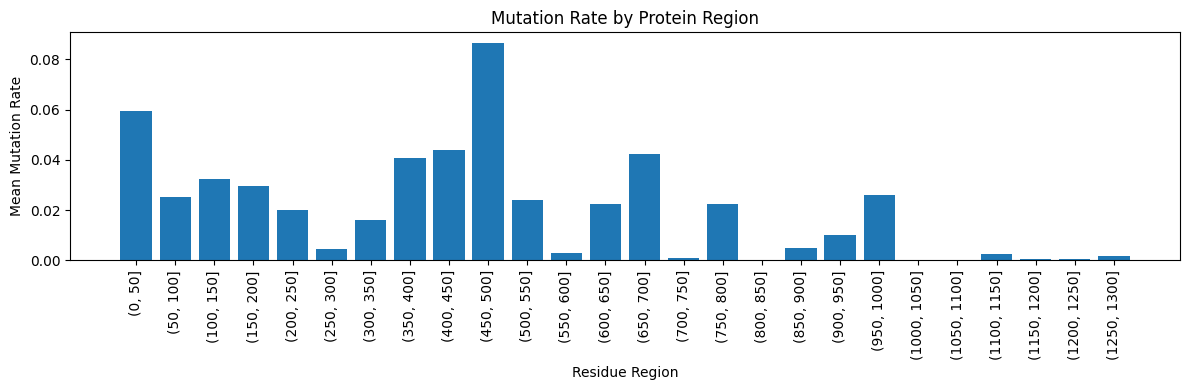

In [79]:
# bar chart for enriched regions

finalseq_df["region"] = pd.cut(
    finalseq_df["wuhan_resnum"],
    bins=range(0, 1350, 50)
)

region_rates = (
    finalseq_df
    .groupby("region")
    .agg(
        mean_mut_rate=("mutation_rate", "mean"),
        hotspot_rate=("hotspot", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(12,4))

plt.bar(
    range(len(region_rates)),
    region_rates["mean_mut_rate"]
)

plt.xticks(
    range(len(region_rates)),
    [str(x) for x in region_rates["region"]],
    rotation=90
)

plt.ylabel("Mean Mutation Rate")
plt.xlabel("Residue Region")
plt.title("Mutation Rate by Protein Region")

plt.tight_layout()
plt.show()

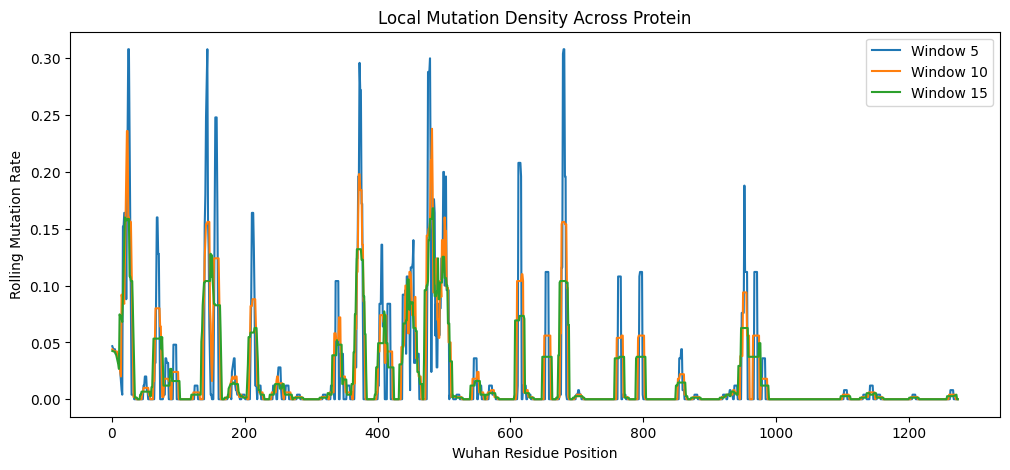

In [86]:
#supplementary density plot to visualize enriched regions

finalseq_df = finalseq_df.sort_values("wuhan_resnum")

for W in [5, 10, 15]:
    finalseq_df[f"mut_rate_roll{W}"] = (
        finalseq_df["mutation_rate"]
        .rolling(
            window=W,
            center=True,
            min_periods=1
        )
        .mean()
    )
plt.figure(figsize=(12,5))

for W in [5, 10, 15]:
    plt.plot(
        finalseq_df["wuhan_resnum"],
        finalseq_df[f"mut_rate_roll{W}"],
        label=f"Window {W}"
    )

plt.xlabel("Wuhan Residue Position")
plt.ylabel("Rolling Mutation Rate")
plt.title("Local Mutation Density Across Protein")
plt.legend()

plt.show()

In [87]:
region = finalseq_df[
    finalseq_df["wuhan_resnum"].between(400,550)
]

print(region["q8"].value_counts(normalize=True),
region["chem_prop"].value_counts(normalize=True),
region["rsa"].describe(),
region["disorder"].describe()
     )

q8
E    0.470199
C    0.417219
T    0.105960
S    0.006623
Name: proportion, dtype: float64 chem_prop
hydrophobic    0.370861
polar          0.251656
special        0.198675
positive       0.105960
negative       0.072848
Name: proportion, dtype: float64 count    151.000000
mean       0.284204
std        0.161927
min        0.020385
25%        0.143362
50%        0.288808
75%        0.394495
max        0.842229
Name: rsa, dtype: float64 count    151.000000
mean       0.017655
std        0.012994
min        0.001166
25%        0.007034
50%        0.014615
75%        0.025955
max        0.062784
Name: disorder, dtype: float64


In [98]:
# compare peak heavy regions based on secondary structures
whole = (
    finalseq_df["q8"]
    .value_counts(normalize=True)
    .mul(100)
)

region_0_200 = (
    finalseq_df.loc[
        finalseq_df["wuhan_resnum"].between(0, 200),
        "q8"
    ]
    .value_counts(normalize=True)
    .mul(100)
)

region_400_550 = (
    finalseq_df.loc[
        finalseq_df["wuhan_resnum"].between(400, 550),
        "q8"
    ]
    .value_counts(normalize=True)
    .mul(100)
)

q8_regions = pd.DataFrame({
    "Whole Protein (%)": whole,
    "Region 0-200 (%)": region_0_200,
    "Region 400-550 (%)": region_400_550
}).fillna(0)

q8_regions = (
    q8_regions
    .round(1)
    .reset_index()
    .rename(columns={"index": "Q8 State"})
)

q8_regions

,q8,Whole Protein (%),Region 0-200 (%),Region 400-550 (%)
0,C,39.0,39.0,41.7
1,E,31.5,48.0,47.0
2,H,20.7,0.0,0.0
3,S,1.3,1.5,0.7
4,T,7.5,11.5,10.6


In [100]:
# compare peak heavy regions based on physicochemical properties
whole = (
    finalseq_df["chem_prop"]
    .value_counts(normalize=True)
    .mul(100)
)

region_0_200 = (
    finalseq_df.loc[
        finalseq_df["wuhan_resnum"].between(0, 200),
        "chem_prop"
    ]
    .value_counts(normalize=True)
    .mul(100)
)

region_400_550 = (
    finalseq_df.loc[
        finalseq_df["wuhan_resnum"].between(400, 550),
        "chem_prop"
    ]
    .value_counts(normalize=True)
    .mul(100)
)

q8_regions = pd.DataFrame({
    "Whole Protein (%)": whole,
    "Region 0-200 (%)": region_0_200,
    "Region 400-550 (%)": region_400_550
}).fillna(0)

q8_regions = (
    q8_regions
    .round(1)
    .reset_index()
    .rename(columns={"index": "chem_prop"})
)

q8_regions

,chem_prop,Whole Protein (%),Region 0-200 (%),Region 400-550 (%)
0,hydrophobic,40.6,42.0,37.1
1,polar,27.2,28.5,25.2
2,special,14.1,11.5,19.9
3,positive,9.4,10.5,10.6
4,negative,8.6,7.5,7.3


###  UMAPs

In [101]:
finalseq_df.columns

Index(['hotspot', 'mutation_rate', 'wuhan_resnum', 'rsa', 'asa', 'q8',
       'p[q8_G]', 'p[q8_H]', 'p[q8_I]', 'p[q8_B]', 'p[q8_E]', 'p[q8_S]',
       'p[q8_T]', 'p[q8_C]', 'disorder', 'kd_ref', 'kd_win9', 'kd_win15',
       'kd_win21', 'chem_prop', 'hydrophobic', 'negative', 'polar', 'positive',
       'special', 'charge_ref', 'charge_win9', 'charge_win15', 'charge_win21',
       'gp_ref', 'gp_win9', 'gp_win15', 'gp_win21', 'region', 'mut_rate_roll',
       'mut_rate_roll9', 'mut_rate_roll15', 'mut_rate_roll21',
       'mut_rate_roll7', 'mut_rate_roll10', 'mut_rate_roll5'],
      dtype='str')

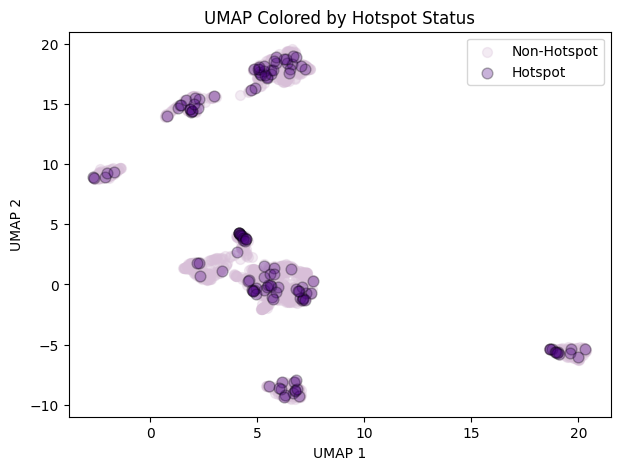

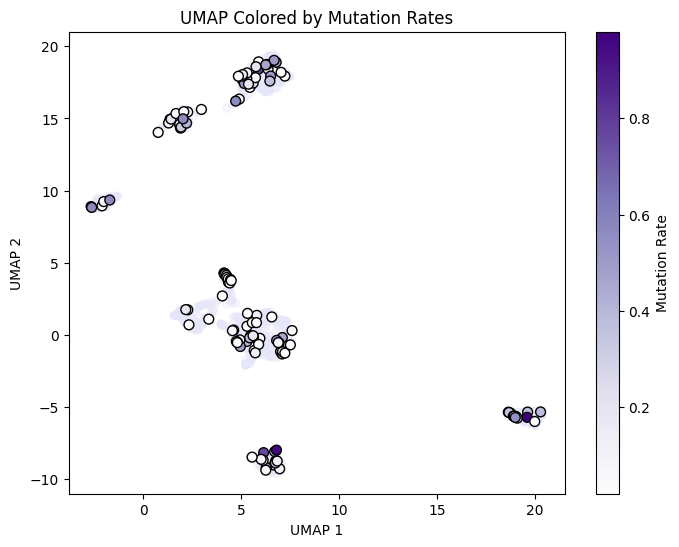

In [144]:
#UMAPS

# Umaps based on hotspot propensity
features = [
    'rsa', 'asa',
    'p[q8_G]', 'p[q8_H]', 'p[q8_I]', 'p[q8_B]', 'p[q8_E]', 'p[q8_S]','p[q8_T]', 'p[q8_C]', 'disorder', 
    'kd_ref', 'kd_win9', 'kd_win15','kd_win21', 'hydrophobic', 'negative', 'polar', 'positive','special',
    'charge_ref', 'charge_win9', 'charge_win15', 'charge_win21',
    'gp_ref', 'gp_win9', 'gp_win15', 'gp_win21'
]

X = finalseq_df[features]
X_scaled = StandardScaler().fit_transform(X)

plt.figure(figsize=(7, 5))

# Non-hotspots 
plt.scatter(
    embedding[finalseq_df["hotspot"] == 0, 0],
    embedding[finalseq_df["hotspot"] == 0, 1],
    color="thistle",      # pastel purple
    alpha=0.3,
    s=50,
    label="Non-Hotspot"
)

# Hotspots (dark purple)
plt.scatter(
    embedding[finalseq_df["hotspot"] == 1, 0],
    embedding[finalseq_df["hotspot"] == 1, 1],
    color="indigo",
    alpha=0.3,
    s=60,
    label="Hotspot",
    edgecolors="black"
)

plt.title("UMAP Colored by Hotspot Status")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.show()


#clusters based on mutation rates

plt.figure(figsize=(8,6))

# background
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    color="lavender",
    alpha=0.3,
    s=30
)

# mutation-prone
high_mut = finalseq_df["mutation_rate"] > 0

plt.scatter(
    embedding[high_mut,0],
    embedding[high_mut,1],
    c=finalseq_df.loc[high_mut,"mutation_rate"],
    cmap="Purples",
    s=50,
    edgecolors="black"
)

plt.colorbar(label="Mutation Rate")
plt.title("UMAP Colored by Mutation Rates")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

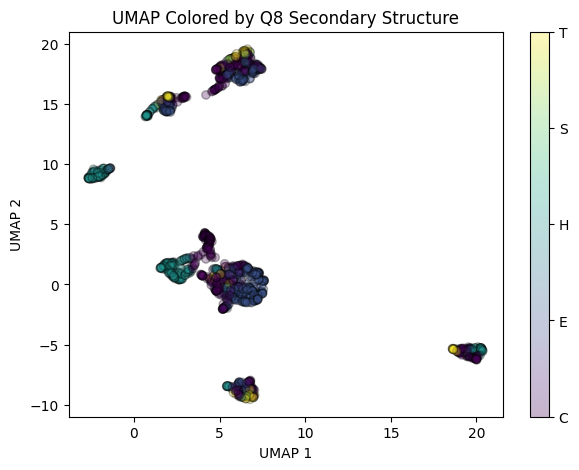

In [137]:
# clusters based on secondary structures

q8_codes = finalseq_df["q8"].astype("category").cat.codes
q8_labels = finalseq_df["q8"].astype("category").cat.categories

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=q8_codes,
    alpha=0.3,
    edgecolors="black"
)

cbar = plt.colorbar(scatter)
cbar.set_ticks(range(len(q8_labels)))
cbar.set_ticklabels(q8_labels)

plt.title("UMAP Colored by Q8 Secondary Structure")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

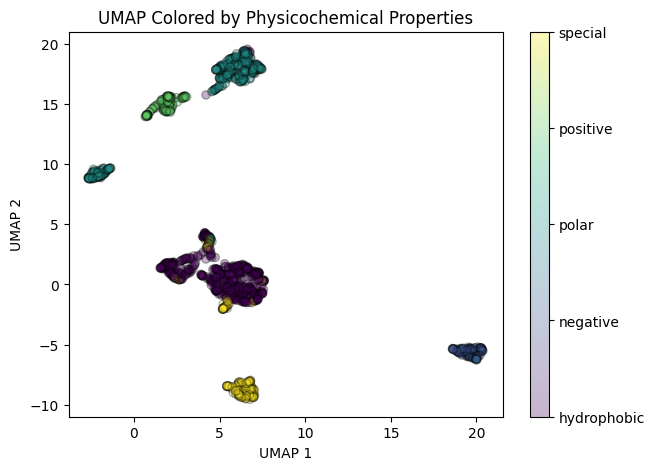

In [141]:
#clusters based on chemical properties

chem_codes = finalseq_df["chem_prop"].astype("category").cat.codes
chem_labels = finalseq_df["chem_prop"].astype("category").cat.categories

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=chem_codes,
    alpha=0.3,
    edgecolors="black"
)

cbar = plt.colorbar(scatter)
cbar.set_ticks(range(len(chem_labels)))
cbar.set_ticklabels(chem_labels)

plt.title("UMAP Colored by Physicochemical Properties")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

In [143]:
pd.crosstab(
    finalseq_df["chem_prop"],
    finalseq_df["hotspot"],
    normalize="index"
)

hotspot,0,1
chem_prop,,
hydrophobic,0.903288,0.096712
negative,0.890909,0.109091
polar,0.890173,0.109827
positive,0.875000,0.125000
special,0.922222,0.077778


### HDBSCAN

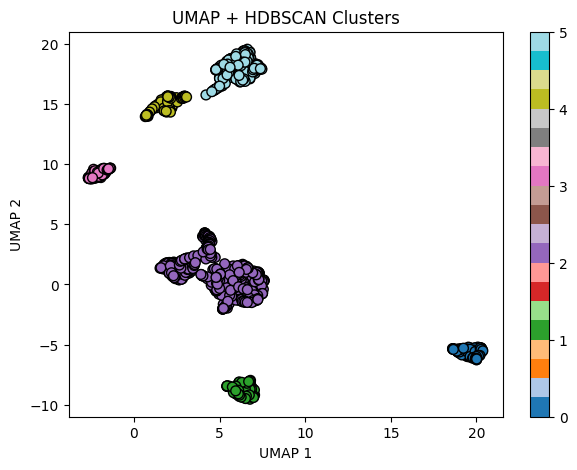

In [150]:
# hdbscan 

clusterer = hdbscan.HDBSCAN(
    min_cluster_size = 20,
    min_samples = 10
)

clusters = clusterer.fit_predict(embedding)
finalseq_df["cluster"] = clusters

plt.figure(figsize=(7,5))

scatter = plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=clusters,
    cmap="tab20",
    s=50,
    edgecolor = "black"
)

plt.colorbar(scatter)
plt.title("UMAP + HDBSCAN Clusters")

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.show()

In [157]:
cluster_summary = (
    finalseq_df
    .groupby("cluster")
    .agg(
        n_positions=("cluster","size"),
        hotspot_rate=("hotspot","mean"),
        mean_mut_rate=("mutation_rate","mean")
    )
    .sort_values(
        "hotspot_rate",
        ascending=False
    )
)

cluster_summary = cluster_summary.reset_index()
cluster_summary

,cluster,n_positions,hotspot_rate,mean_mut_rate
0,4,120,0.125000,0.022333
1,5,264,0.113636,0.029924
2,0,112,0.107143,0.029821
3,1,134,0.097015,0.028060
4,2,567,0.095238,0.011429
5,3,76,0.065789,0.022895


In [155]:
pd.crosstab(
    finalseq_df["cluster"],
    finalseq_df["q8"],
    normalize = "index"
)

q8,C,E,H,S,T
cluster,,,,,
0,0.428571,0.205357,0.250000,0.017857,0.098214
1,0.477612,0.194030,0.082090,0.029851,0.216418
2,0.358025,0.407407,0.220459,0.000000,0.014109
3,0.052632,0.000000,0.947368,0.000000,0.000000
4,0.341667,0.316667,0.208333,0.033333,0.100000
5,0.518939,0.314394,0.007576,0.026515,0.132576


In [156]:
pd.crosstab(
    finalseq_df["cluster"],
    finalseq_df["chem_prop"],
    normalize = "index"
)

chem_prop,hydrophobic,negative,polar,positive,special
cluster,,,,,
0,0.008929,0.982143,0.008929,0.0,0.000000
1,0.000000,0.000000,0.000000,0.0,1.000000
2,0.901235,0.000000,0.017637,0.0,0.081129
3,0.000000,0.000000,1.000000,0.0,0.000000
4,0.000000,0.000000,0.000000,1.0,0.000000
5,0.018939,0.000000,0.981061,0.0,0.000000
